In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt

from robotblockset.tools import get_rbs_path

np.set_printoptions(precision=3, suppress=True, linewidth=100)

In [3]:
from robotblockset.mujoco.scene_pymujoco_sim import mujoco_scene
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/panda_box_scene.xml"
scene = mujoco_scene(MODEL_PATH, show_camera=None, verbose=1)

In [4]:
from robotblockset.mujoco.robots_pymujoco_sim import panda
r = panda(scene=scene)

[RBS_INFO] [1773555921.164587975] [panda_PyMuJoCo]: Robot connected to MuJoCo


In [5]:
# Callback for Update
it = 0
def CaptureRobot_v(r):
    global it, tt, twall, trob, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt, xtw, vtw, rxtw, rvtw, rrxtw, rrvtw, rTbt, tc, frames, tframes, last_time, framerate
    if r.t - last_time >= 1/framerate:
        last_time = r.t
        pixels = r.scene.mj_capture_camera(width=640, height=480)
        frames.append(pixels)
        tframes.append(r.t)
        
    if it == 0:
        tt = np.array(r.t)
        twall = time.time()
        trob = r._robottime
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
        xtw = r.x
        vtw = r.v
        rxtw = r.x_ref
        rvtw = r.v_ref
        rrxtw = r._command.rx
        rrvtw = r._command.rv
        rTbt = r.GetBasePose(out="x")
        tc = r._last_control_time
    else:
        tt = np.vstack((tt, r.t))
        twall = np.vstack((twall, time.time()))
        trob = np.vstack((trob, r._robottime))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
        xtw = np.vstack((xtw, r.x))
        vtw = np.vstack((vtw, r.v))
        rxtw = np.vstack((rxtw, r.x_ref))
        rvtw = np.vstack((rvtw, r.v_ref))
        rrxtw = np.vstack((rrxtw, r._command.rx))
        rrvtw = np.vstack((rrvtw, r._command.rv))
        rTbt = np.vstack((rTbt, r.GetBasePose(out="x")))
        tc = np.vstack((tc, r._last_control_time))

    it += 1


In [6]:
r.SetCaptureCallback(CaptureRobot_v)
# r.Restart()
r.ResetTime()
it = 0
frames = []
tframes = []
last_time = r.t
framerate = 25

r.StartCapture()
r.JMove(r.q_home,1)
r.Wait(1)
r.CMoveFor([-0.1, 0, -0.2],1)
r.Wait(1)
r.CMoveFor([0.05, 0.1, 0.1],1)
r.StopCapture()
print(f"Captured {len(frames)} frames in {r.t:.2f} seconds")

Captured 149 frames in 6.04 seconds


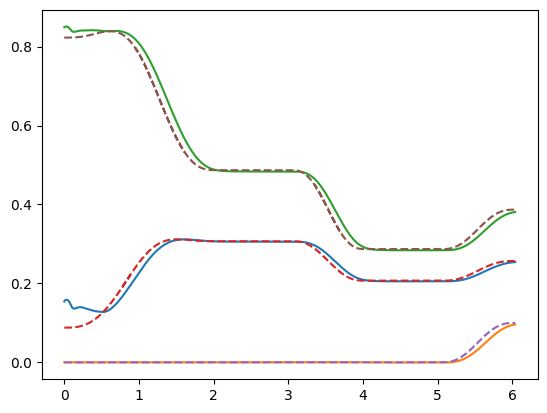

In [7]:
_ = plt.plot(tt,xt[:,:3], tt, rxt[:,:3], "--")

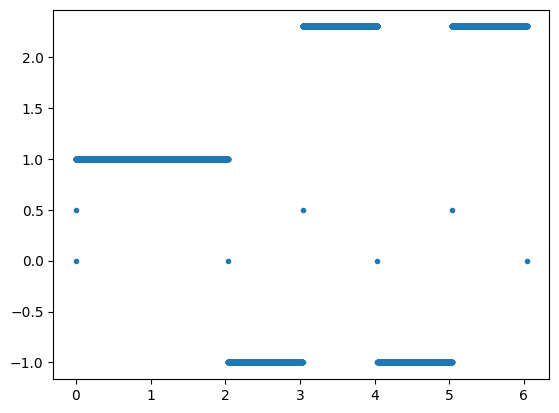

In [8]:
_ = plt.plot(tt,mt, ".")

""

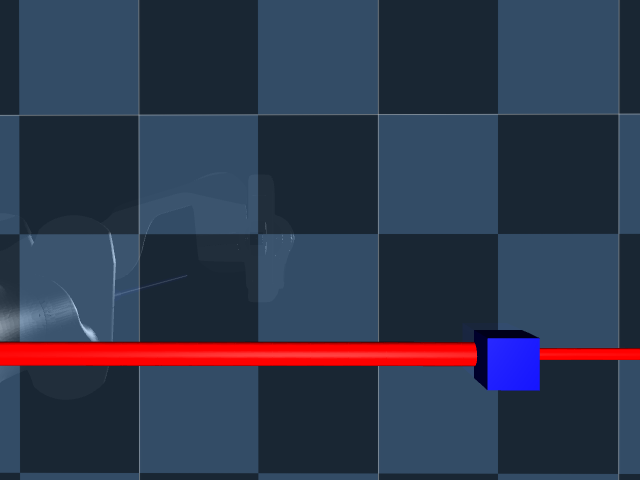

In [9]:
frame = r.scene.mj_capture_camera(camera="Robot", width=640, height=480)
media.show_image(frame)

In [10]:
media.show_video(frames, fps=framerate)

This browser does not support the video tag.
